# Tutorial 04 · Two-Sensor Multi-Qubit Readout

This notebook extends the previous tutorials to a more realistic setting:

- multiple quantum dots
- two sensors
- shared detuning noise
- sensor-dependent `I/Q` responses

The main question is:

> **How do two sensors respond differently to the same noisy multi-qubit system?**



In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().parent if Path.cwd().name == 'tutorials' else Path.cwd()
sys.path.append(str(repo_root / 'src'))

from readout_simulator import QuantumDotSystem, RLC_sensor, generate_sensor_iq_dataset
from readout_simulator.helper_functions import plot_coulomb_peak_minimal
from readout_simulator.noise_models import SpectrumNoise

plt.style.use('default')
plt.rcParams.update({
    'figure.dpi': 125,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'grid.color': '#cbd5e1',
    'axes.facecolor': '#fcfcfe',
})



## 1. Define a Multi-Qubit, Two-Sensor System

This is the main configuration cell.
If you want to adapt the tutorial, these are the most important objects to change:

- `Cdd`: dot-dot coupling structure
- `Cds`: how strongly each dot couples to each sensor
- `charge_states`: which multi-qubit states you want to compare
- the `sensors` list: one `RLC_sensor` per sensor channel

For a clearer tutorial separation, we choose two deliberately distinct states:

- a **left-heavy** state
- a **right-heavy** state

and we make the sensor couplings more local so Sensor 1 prefers the left side while Sensor 2 prefers the right side.


In [13]:
dot_system = QuantumDotSystem(
    Cdd=np.array([
        [1.0, -0.18, -0.05, -0.02],
        [-0.18, 1.0, -0.21, -0.05],
        [-0.05, -0.21, 1.0, -0.17],
        [-0.02, -0.05, -0.17, 1.0],
    ]),
    Cds=np.array([
        [0.42, 0.06],
        [0.30, 0.10],
        [0.10, 0.30],
        [0.06, 0.42],
    ]),
)

sensor_1 = RLC_sensor(
    {'Lc': 800e-9, 'Cp': 0.5e-12, 'RL': 40, 'Rc': 0.0, 'Z0': 50},
    {'g0': 1/50, 'eps0': 0.42, 'eps_width': 1.0},
)
sensor_2 = RLC_sensor(
    {'Lc': 820e-9, 'Cp': 0.55e-12, 'RL': 40, 'Rc': 0.0, 'Z0': 50},
    {'g0': 1/55, 'eps0': 0.48, 'eps_width': 1.0},
)
sensors = [sensor_1, sensor_2]

charge_states = np.array([
    [0, 1, 0, 0],
    [0, 0, 1, 0],
])
charge_state_labels = ['Left-heavy [0,1,0,0]', 'Right-heavy [0,0,1,0]']

times = np.arange(0, 1.2e-6, 1e-9)
times_ns = 1e9 * times
integration_times_ns = np.array([25, 60, 120, 250, 500])
integration_indices = np.clip((integration_times_ns - 1).astype(int), 0, len(times) - 1)

simulation_params = {'eps0': 0.0}


[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 0.000e+00 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: None
  Energy noise model: None
[RLC_sensor] Initialized with:
  Lc = 8.200e-07 H
  Cp = 5.500e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.500e-13 F
  RL = 40 Ω
  Rc = 0.000e+00 Ω
  Z0 = 50 Ω
  R0 = 5.500e+01 Ω
  g0 = 1.818e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.370e+08 Hz
  Resonant period = 4.220e-09 s
  Capacitance noise model: None
  Energy noise model: None


## 2. Shared Noise Model

We again use a shared `1/f` trajectory $\rightarrow$ both sensors see the same underlying fluctuating dot system


In [ ]:
def psd_1f(freq):
    return np.where(freq > 0, 1 / freq, 0.0)

noise_model = SpectrumNoise(psd_func=psd_1f, sigma=0.26)
n_realisations = 100 # reduce number to speed up the simulation



## 3. Generate the Dataset

The dataset generator now returns one extra sensor dimension.
Everything else stays conceptually similar to tutorial 03, which is useful because it means the single-sensor and two-sensor workflows align well.



In [21]:
dataset = generate_sensor_iq_dataset(
    dot_system=dot_system,
    sensors=sensors,
    charge_states=charge_states,
    times=times,
    simulation_params=simulation_params,
    noise_model=noise_model,
    n_realisations=n_realisations,
    integration_indices=integration_indices,
    use_stationary_initial_state=True,
)

I_raw = dataset['I_raw']
Q_raw = dataset['Q_raw']
I_int = dataset['I_integrated']
Q_int = dataset['Q_integrated']
I_points = dataset['I_points']
Q_points = dataset['Q_points']
shared_noise = dataset['shared_noise']



C:\Users\rouvenkoch\AppData\Local\Temp\ipykernel_14376\2100187123.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.where(freq > 0, 1 / freq, 0.0)


## 4. Inspect Both Sensor Operating Points on Their Conductance Peaks

The two sensors do not only differ by geometry.
They also use slightly different resonator and Coulomb-peak parameters.

This figure shows how the same pair of multi-qubit states projects onto each sensor's conductance curve.



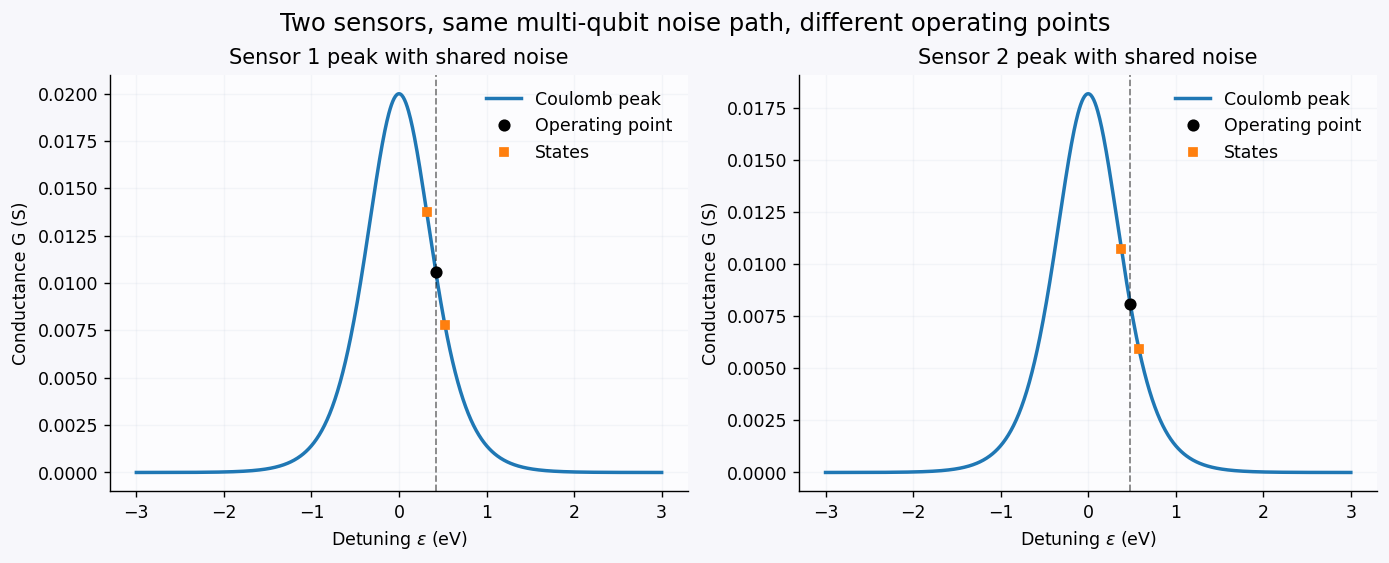

In [22]:
offsets_state_a = dot_system.get_energy_offset(charge_states[0], np.zeros(len(sensors)), eps0=0.0)
offsets_state_b = dot_system.get_energy_offset(charge_states[1], np.zeros(len(sensors)), eps0=0.0)
delta_offsets = np.abs(offsets_state_b - offsets_state_a)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.1), constrained_layout=True)
fig.patch.set_facecolor('#f7f7fb')

sensor_peak_params = [
    {
        'g0': 1 / sensor_1.R0,
        'eps0': sensor_1.eps0 / sensor_1.eps_w,
        'eps_width': sensor_1.eps_w,
    },
    {
        'g0': 1 / sensor_2.R0,
        'eps0': sensor_2.eps0 / sensor_2.eps_w,
        'eps_width': sensor_2.eps_w,
    },
]

for sensor_idx, ax in enumerate(axes):
    plot_coulomb_peak_minimal(
        sensor_peak_params[sensor_idx],
        delta_eps=delta_offsets[sensor_idx],
        eps_noise=None, #shared_noise[0],
        ax=ax,
    )
    ax.set_title(f'Sensor {sensor_idx + 1} peak with shared noise', fontsize=12)

fig.suptitle('Two sensors, same multi-qubit noise path, different operating points', fontsize=14, y=1.06)
plt.show()



## 5. Shared Noise and Sensor-Specific I and Q Traces

The first figure compares:

- the common noise trajectory
- sensor 1's I and Q response for both charge states
- sensor 2's I and Q response for both charge states

This highlights the basic idea of multi-sensor readout: the same fluctuating system can project differently onto different sensors and into different demodulation quadratures.



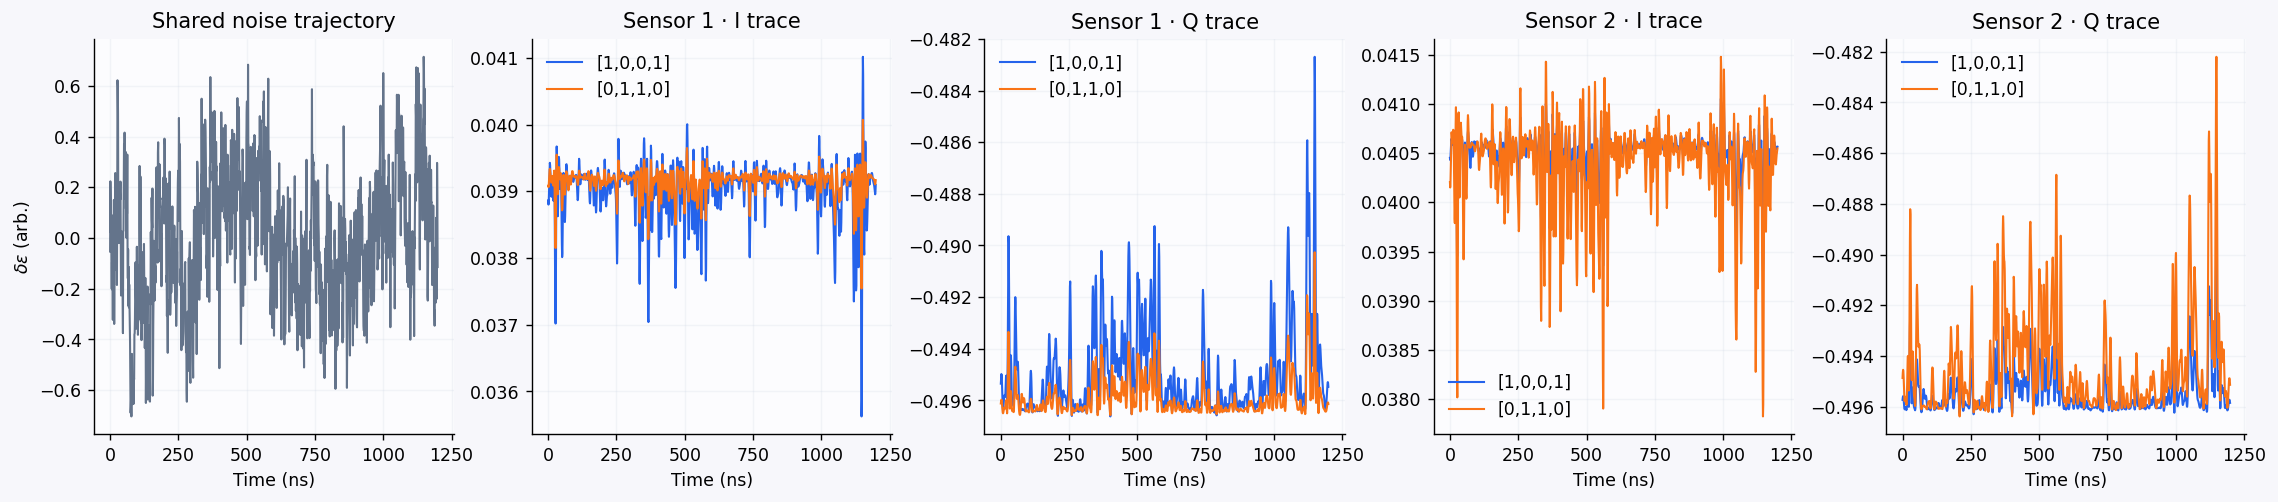

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(18.0, 3.9), constrained_layout=True)
fig.patch.set_facecolor('#f7f7fb')

axes[0].plot(times_ns, shared_noise[0], color='#64748B', lw=1.2)
axes[0].set_title('Shared noise trajectory', fontsize=12)
axes[0].set_xlabel('Time (ns)')
axes[0].set_ylabel('$\\delta \\epsilon$ (arb.)')

axes[1].plot(times_ns, I_raw[0, 0, 0], color='#2563EB', lw=1.2, label='[1,0,0,1]')
axes[1].plot(times_ns, I_raw[1, 0, 0], color='#F97316', lw=1.2, label='[0,1,1,0]')
axes[1].set_title('Sensor 1 · I trace', fontsize=12)
axes[1].set_xlabel('Time (ns)')
axes[1].legend(frameon=False)

axes[2].plot(times_ns, Q_raw[0, 0, 0], color='#2563EB', lw=1.2, label='[1,0,0,1]')
axes[2].plot(times_ns, Q_raw[1, 0, 0], color='#F97316', lw=1.2, label='[0,1,1,0]')
axes[2].set_title('Sensor 1 · Q trace', fontsize=12)
axes[2].set_xlabel('Time (ns)')
axes[2].legend(frameon=False)

axes[3].plot(times_ns, I_raw[0, 0, 1], color='#2563EB', lw=1.2, label='[1,0,0,1]')
axes[3].plot(times_ns, I_raw[1, 0, 1], color='#F97316', lw=1.2, label='[0,1,1,0]')
axes[3].set_title('Sensor 2 · I trace', fontsize=12)
axes[3].set_xlabel('Time (ns)')
axes[3].legend(frameon=False)

axes[4].plot(times_ns, Q_raw[0, 0, 1], color='#2563EB', lw=1.2, label='[1,0,0,1]')
axes[4].plot(times_ns, Q_raw[1, 0, 1], color='#F97316', lw=1.2, label='[0,1,1,0]')
axes[4].set_title('Sensor 2 · Q trace', fontsize=12)
axes[4].set_xlabel('Time (ns)')
axes[4].legend(frameon=False)

# fig.suptitle('One noise source, two sensor responses in I and Q', fontsize=14, y=1.05)
plt.show()


## 6. Sensor 1 and Sensor 2 Time-Domain I and Q Traces

To compare the two sensors more directly, we now look at both the raw and running-average integrated `I` and `Q` signals for one realisation.
This makes it easier to see:

- where the state contrast first appears in time
- whether the contrast is stronger in `I`, `Q`, or both
- how integration stabilises the separation in each channel


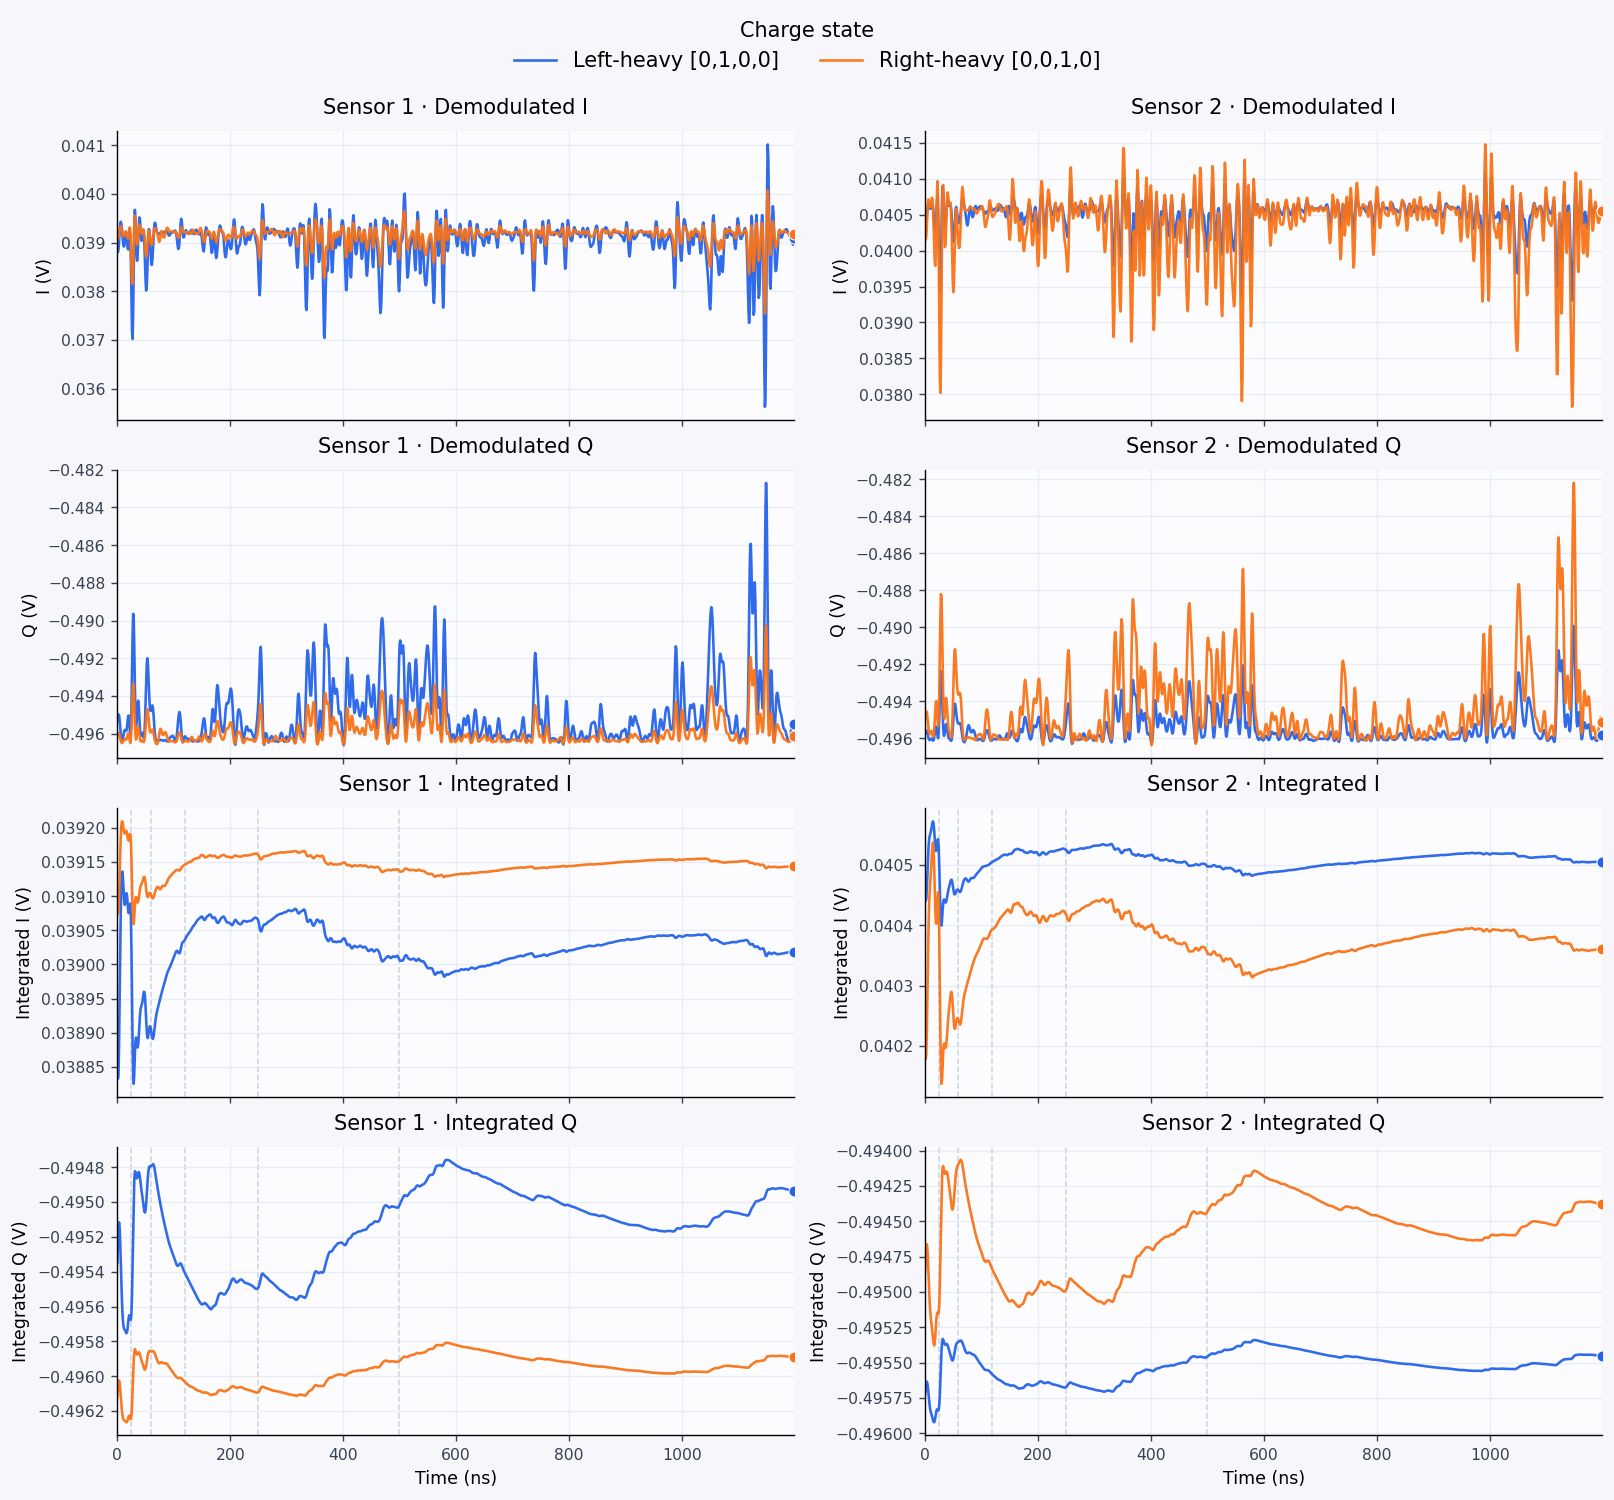

In [28]:
state_colours = ['#2563EB', '#F97316']
sensor_names = ['Sensor 1', 'Sensor 2']
time_lo = np.percentile(times_ns, 0.0)
time_hi = np.percentile(times_ns, 100.0)

fig, axes = plt.subplots(4, 2, figsize=(12.8, 11.2), constrained_layout=True, sharex=True)
fig.patch.set_facecolor('#f7f7fb')

for sensor_idx, sensor_name in enumerate(sensor_names):
    i_ax = axes[0, sensor_idx]
    q_ax = axes[1, sensor_idx]
    i_int_ax = axes[2, sensor_idx]
    q_int_ax = axes[3, sensor_idx]

    for state_idx, label in enumerate(charge_state_labels):
        i_trace = I_raw[state_idx, 0, sensor_idx]
        q_trace = Q_raw[state_idx, 0, sensor_idx]
        i_int_trace = I_int[state_idx, 0, sensor_idx]
        q_int_trace = Q_int[state_idx, 0, sensor_idx]

        i_ax.plot(times_ns, i_trace, color=state_colours[state_idx], lw=1.5, alpha=0.95, label=label)
        q_ax.plot(times_ns, q_trace, color=state_colours[state_idx], lw=1.5, alpha=0.95, label=label)
        i_int_ax.plot(times_ns, i_int_trace, color=state_colours[state_idx], lw=1.5, alpha=0.95, label=label)
        q_int_ax.plot(times_ns, q_int_trace, color=state_colours[state_idx], lw=1.5, alpha=0.95, label=label)

        i_ax.scatter(times_ns[-1], i_trace[-1], s=40, color=state_colours[state_idx], edgecolor='white', linewidth=0.6, zorder=4)
        q_ax.scatter(times_ns[-1], q_trace[-1], s=40, color=state_colours[state_idx], edgecolor='white', linewidth=0.6, zorder=4)
        i_int_ax.scatter(times_ns[-1], i_int_trace[-1], s=40, color=state_colours[state_idx], edgecolor='white', linewidth=0.6, zorder=4)
        q_int_ax.scatter(times_ns[-1], q_int_trace[-1], s=40, color=state_colours[state_idx], edgecolor='white', linewidth=0.6, zorder=4)

    for idx in integration_indices:
        i_int_ax.axvline(times_ns[idx], color='#CBD5E1', lw=0.9, ls='--', zorder=0)
        q_int_ax.axvline(times_ns[idx], color='#CBD5E1', lw=0.9, ls='--', zorder=0)

    i_ax.set_title(f'{sensor_name} · Demodulated I', fontsize=12, pad=10)
    q_ax.set_title(f'{sensor_name} · Demodulated Q', fontsize=12, pad=10)
    i_int_ax.set_title(f'{sensor_name} · Integrated I', fontsize=12, pad=10)
    q_int_ax.set_title(f'{sensor_name} · Integrated Q', fontsize=12, pad=10)

    i_ax.set_ylabel('I (V)', fontsize=10)
    q_ax.set_ylabel('Q (V)', fontsize=10)
    i_int_ax.set_ylabel('Integrated I (V)', fontsize=10)
    q_int_ax.set_ylabel('Integrated Q (V)', fontsize=10)
    q_int_ax.set_xlabel('Time (ns)', fontsize=10)

    for ax in (i_ax, q_ax, i_int_ax, q_int_ax):
        ax.set_xlim(time_lo, time_hi)
        ax.grid(True, color='#dbe3ef', alpha=0.60, linewidth=0.8)
        ax.tick_params(labelsize=9, colors='#374151')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.065), ncol=2, frameon=False, title='Charge state', fontsize=12, title_fontsize=12)
plt.show()


## 7. Integrated IQ Clouds for Both Sensors

Finally, we compare the sampled integrated IQ points for both sensors.
Each row is one sensor, and each column is one integration time.

The plotting choices here are meant to make the comparison easier to read:

- separate row-wise `I` and `Q` spans so each sensor keeps its natural cloud shape
- large centroid markers for each state
- a dashed connector between centroids to show how the state separation grows with integration time


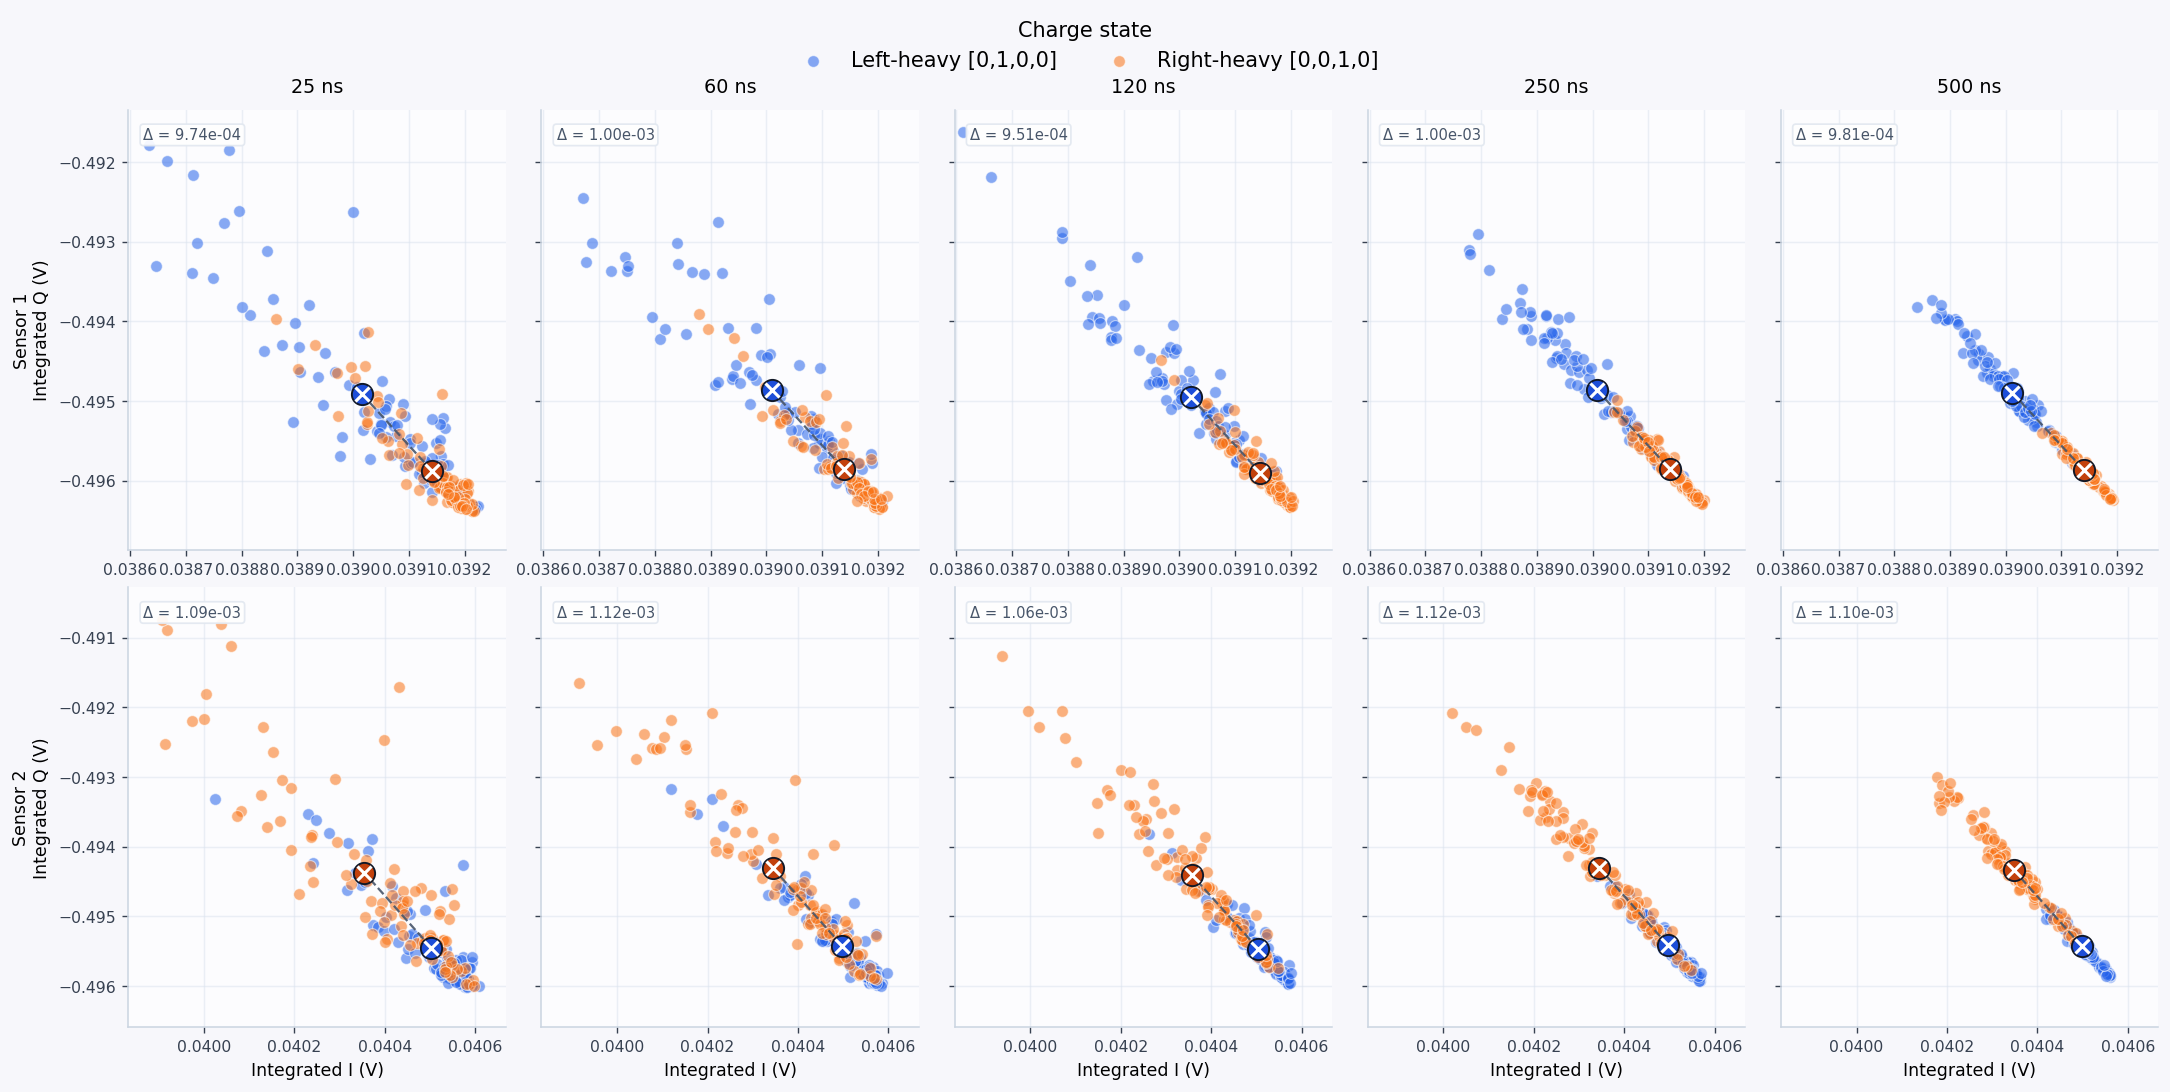

In [29]:
state_colours = ['#2563EB', '#F97316']
state_mean_colours = ['#1D4ED8', '#C2410C']
n_sensors = len(sensors)
n_times = len(integration_times_ns)

fig, axes = plt.subplots(
    n_sensors,
    n_times,
    figsize=(3.45 * n_times, 4.05 * n_sensors),
    constrained_layout=True,
    sharex='row',
    sharey='row',
)
fig.patch.set_facecolor('#f7f7fb')

if n_sensors == 1:
    axes = axes[np.newaxis, :]

for sensor_idx in range(n_sensors):
    sensor_i = I_points[:, :, sensor_idx, :]
    sensor_q = Q_points[:, :, sensor_idx, :]
    x_lo, x_hi = np.quantile(sensor_i, [0.01, 0.99])
    y_lo, y_hi = np.quantile(sensor_q, [0.01, 0.99])
    x_center = 0.5 * (x_lo + x_hi)
    y_center = 0.5 * (y_lo + y_hi)
    x_half_span = 0.62 * max(x_hi - x_lo, 1e-9)
    y_half_span = 0.62 * max(y_hi - y_lo, 1e-9)

    for col_idx, time_ns in enumerate(integration_times_ns):
        ax = axes[sensor_idx, col_idx]
        ax.set_facecolor('#fcfcfe')

        centroids = []
        for state_idx, label in enumerate(charge_state_labels):
            x = I_points[state_idx, :, sensor_idx, col_idx]
            y = Q_points[state_idx, :, sensor_idx, col_idx]
            x_mean = np.mean(x)
            y_mean = np.mean(y)
            centroids.append((x_mean, y_mean))

            ax.scatter(
                x,
                y,
                s=46,
                alpha=0.55,
                color=state_colours[state_idx],
                edgecolor='white',
                linewidth=0.65,
                label=label if (sensor_idx == 0 and col_idx == 0) else None,
                zorder=2,
            )
            ax.scatter(
                x_mean,
                y_mean,
                s=150,
                color=state_mean_colours[state_idx],
                edgecolor='#111827',
                linewidth=1.1,
                zorder=5,
            )
            ax.plot(
                x_mean,
                y_mean,
                marker='x',
                markersize=8,
                markeredgewidth=1.8,
                color='white',
                zorder=6,
            )

        ax.plot(
            [centroids[0][0], centroids[1][0]],
            [centroids[0][1], centroids[1][1]],
            ls='--',
            lw=1.3,
            color='#475569',
            alpha=0.9,
            zorder=4,
        )

        separation = np.hypot(
            centroids[1][0] - centroids[0][0],
            centroids[1][1] - centroids[0][1],
        )
        ax.text(
            0.04,
            0.96,
            f'Δ = {separation:.2e}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=8.5,
            color='#475569',
            bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='#E2E8F0', alpha=0.92),
        )

        if sensor_idx == 0:
            ax.set_title(f'{time_ns} ns', fontsize=11, pad=10)
        if col_idx == 0:
            ax.set_ylabel(f'Sensor {sensor_idx + 1}\nIntegrated Q (V)', fontsize=10)
        if sensor_idx == n_sensors - 1:
            ax.set_xlabel('Integrated I (V)', fontsize=10)

        ax.set_xlim(x_center - x_half_span, x_center + x_half_span)
        ax.set_ylim(y_center - y_half_span, y_center + y_half_span)
        ax.set_aspect('auto')
        ax.grid(True, color='#dbe3ef', alpha=0.54, linewidth=0.85)
        ax.tick_params(labelsize=9, colors='#374151')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('#cbd5e1')
        ax.spines['bottom'].set_color('#cbd5e1')
        ax.spines['left'].set_linewidth(0.9)
        ax.spines['bottom'].set_linewidth(0.9)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.07),
    ncol=2,
    frameon=False,
    title='Charge state',
    fontsize=12,
    title_fontsize=12,
)
plt.show()


## Takeaway

- Two sensors can respond very differently to the same noisy multi-qubit system
- Shared-noise simulations are useful for understanding how much of the structure is due to geometry and operating point rather than random noise differences
- Conductance-peak plots help explain why one sensor may separate states more strongly than another
- Looking at both time-domain traces and integrated IQ clouds connects raw readout behaviour to dataset-level state separation
